In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pygdsm
import healpy as hp
import pathlib

# Load custom modules
from highz_exp.file_load import DSFileLoader

# Import the some plotting helpers
from highz_exp.plotter import generate_static_hp_map, visualize_static_hmap
from highz_exp.feko_utils import AntennaGain

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Update as needed
ant_4 = pathlib.Path("/mnt/c/Users/Peterson Lab/Documents/highz2026/Discone_Antenna4_Effective_Height.csv")
ant_3 = pathlib.Path("/mnt/c/Users/Peterson Lab/Documents/highz2026/Discone_Antenna3_Effective_Height.csv")
ant_2 = pathlib.Path("/mnt/c/Users/Peterson Lab/Documents/highz2026/Discone_Antenna2_Effective_Height.csv")
ant_1 = pathlib.Path("/mnt/c/Users/Peterson Lab/Documents/highz2026/Discone_Antenna1_Effective_Height.csv")

------------------------------
Column Names in Gain Pattern File:
Index(['Frequency (Hz)', 'IncidentTheta (deg)', 'IncidentPhi (deg)',
       'Impedance_Real (Ohm)', 'Impedance_Imag (Ohm)', 'Voltage_Real (V)',
       'Voltage_Imag (V)', 'Current_Real (A)', 'Current_Imag (A)',
       'Power (W)'],
      dtype='str')


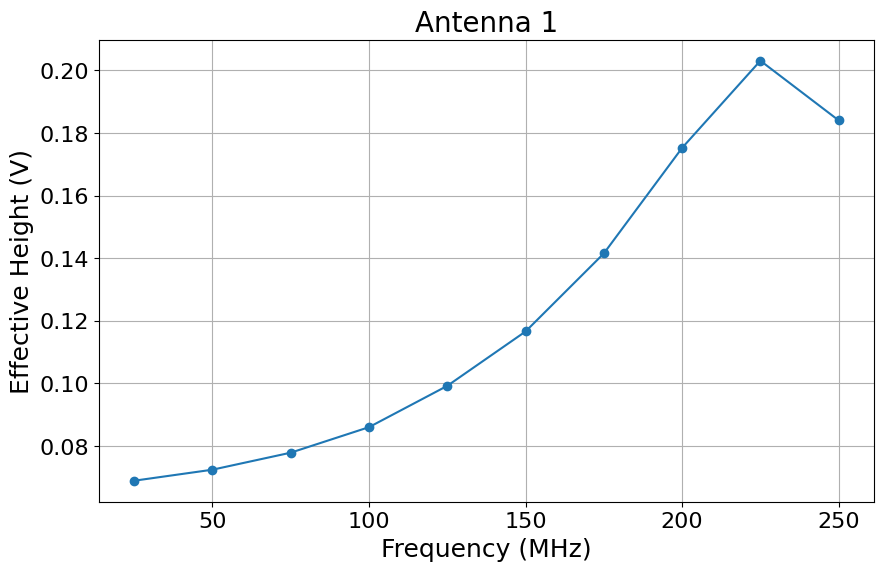

In [6]:
# look at one example antenna gain pattern file
import pandas as pd
import numpy as np
import healpy as hp

# Import the some plotting helpers.
gain_info = pd.read_csv(ant_1)

# # Read what's included in the file
# print("Antenna Gain Pattern Information:")
# print(gain_info.head(2))

# # Print a list of column names
print("------------------------------")
print("Column Names in Gain Pattern File:")
print(gain_info.columns)

gain_info['Voltage_Mag'] = (np.sqrt(gain_info['Voltage_Real (V)']**2 + gain_info['Voltage_Imag (V)']**2))

antenna_gain = AntennaGain(gain_info)

max_gain_df = antenna_gain.eff_height_freq_plot('Antenna 1')

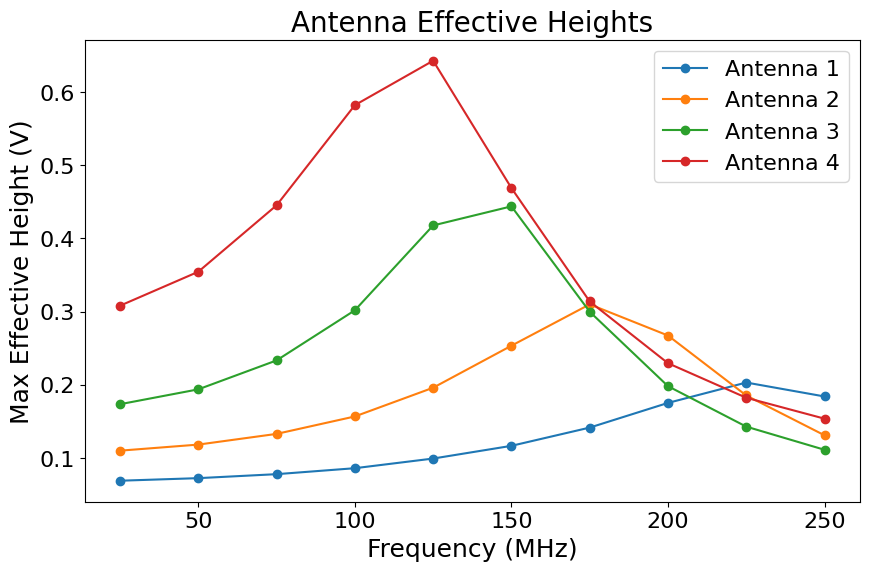

In [11]:
# plot all antennas together
titles = ['Antenna 1', 'Antenna 2', 'Antenna 3', 'Antenna 4']
files = [ant_1, ant_2, ant_3, ant_4]
max_gain_dfs = []
for file in files:
    gain_info = pd.read_csv(file)
    gain_info['Voltage_Mag'] = (np.sqrt(gain_info['Voltage_Real (V)']**2 + gain_info['Voltage_Imag (V)']**2))
    antenna_gain = AntennaGain(gain_info)
    max_gain_df = antenna_gain.load_max_gain()
    max_gain_dfs.append(max_gain_df)

plt.figure(figsize=(10, 6))
for title, max_gain_df in zip(titles, max_gain_dfs):
    plt.plot(max_gain_df['Frequency (Hz)']/1e6, max_gain_df['Voltage_Mag'], label=title, marker='o')

plt.ylabel('Max Effective Height (V)')
plt.xlabel('Frequency (MHz)')
plt.title('Antenna Effective Heights')
plt.legend()
plt.show()